In [ ]:
!pip install -q torch transformers datasets
!pip install -q bitsandbytes >=0.41.0
!pip install -q autoawq
!pip install -q accelerate
!pip install -q jupyter matplotlib pandas
!pip install -q llmcompressor

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5/295.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.6/563.6 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 6.6 MB/s eta 0:00:00
   ━━━━

In [ ]:
import torch, json, os
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

from llmcompressor import oneshot
from llmcompressor.modifiers.quantization import QuantizationModifier
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math

#Step 1- Shared Perplexity Function

def get_wikitext_data(tokenizer, num_samples= 50, seq_len = 512):
    """Load WikiText-2 — the standard perplexity benchmark."""
    dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
    text = "\n\n".join(dataset["text"])
    encodings = tokenizer(text, return_tensors="pt")
    # Take first num_samples * seq_len tokens
    input_ids = encodings.input_ids[:, : num_samples * seq_len]
    input_ids = input_ids.reshape(num_samples, seq_len)
    return input_ids

def compute_perplexity(model, tokenizer, device="cuda", num_samples=50, seq_len=512):
    """
    Compute perplexity on WikiText-2 test set.
    Returns float — lower is better, GPT-2 baseline ~29-30.
    """
    model.eval()
    input_ids = get_wikitext_data(tokenizer, num_samples, seq_len).to(device)

    nlls = []
    with torch.no_grad():
        for i in range(num_samples):
            batch = input_ids[i].unsqueeze(0)        # (1, seq_len)
            outputs = model(batch, labels=batch)
            # outputs.loss = mean NLL over tokens
            nlls.append(outputs.loss.item())

    avg_nll = sum(nlls) / len(nlls)
    perplexity = math.exp(avg_nll)
    return round(perplexity, 2)

# Step 2- FP16 Baseline

MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DEVICE = "cuda"

def run_baseline():
    print("Loading GPT-2 FP16 baseline...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        device_map="auto"

    )

    ppl = compute_perplexity(model, tokenizer, device=DEVICE)
    size_mb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6

    result = {
        "method": "FP16 baseline",
        "perplexity": ppl,
        "model_size_mb": round(size_mb, 1),
        "compression_ratio": 1.0
    }
    print(f"FP16 Perplexity: {ppl} | Size: {size_mb:.0f} MB")
    return result

if __name__ == "__main__":
    baseline_result = run_baseline()

# Step 3- INT8 Quantization

def run_int8():
    print("Loading TinyLlama with INT8 quantization (bitsandbytes)...")

    bnb_config = BitsAndBytesConfig(load_in_8bit=True)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto"
    )

    ppl = compute_perplexity(model, tokenizer, device=DEVICE)

    # Measure actual memory footprint
    size_mb = sum(
        p.numel() * p.element_size() for p in model.parameters()
    ) / 1e6

    result = {
        "method": "INT8 (bitsandbytes LLM.int8())",
        "perplexity": ppl,
        "model_size_mb": round(size_mb, 1),
        "compression_ratio": round(240 / size_mb, 2)  # vs FP16 baseline
    }
    print(f"INT8 Perplexity: {ppl} | Size: {size_mb:.0f} MB")
    return result

if __name__ == "__main__":
    int8_result = run_int8()
    # Append to results


#Step 4 - AWQ Quantization

AWQ_SAVE_PATH = "/content/drive/MyDrive/llm-quantization-benchmark/tinyllama-awq-int4"



def run_awq_llmcompressor():
    print("Loading model...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        device_map="auto"
    )

    # INT4 weight-only quantization — equivalent to AWQ
    recipe = QuantizationModifier(
        targets="Linear",
        scheme="W4A16",        # INT4 weights, FP16 activations — same as AWQ
        ignore=["lm_head"]     # don't quantize the output head
    )

    print("Quantizing with llm-compressor (W4A16)...")
    oneshot(
        model=model,
        recipe=recipe,
        output_dir=AWQ_SAVE_PATH
    )
    print(f"Saved to {AWQ_SAVE_PATH}")
    return model, tokenizer


def evaluate_llmcompressor(model, tokenizer):
    ppl = compute_perplexity(model, tokenizer, device="cuda")

    # Read actual compressed model file size directly
    safetensors_path = os.path.join(AWQ_SAVE_PATH, "model.safetensors")
    size_mb = round(os.path.getsize(safetensors_path) / 1e6, 1)

    result = {
        "method": "INT4 W4A16 (llm-compressor)",
        "perplexity": ppl,
        "model_size_mb": size_mb,
        "compression_ratio": round(baseline_result["model_size_mb"] / size_mb, 2)
    }
    print(f"INT4 Perplexity: {ppl} | Size: {size_mb:.0f}MB")
    return result


# Run it
if not os.path.exists(AWQ_SAVE_PATH):
    model_int4, tokenizer_int4 = run_awq_llmcompressor()
else:
    print("Found saved model, loading...")
    model_int4 = AutoModelForCausalLM.from_pretrained(
        AWQ_SAVE_PATH,
        torch_dtype=torch.float16,
        device_map="auto"
    )
    tokenizer_int4 = AutoTokenizer.from_pretrained(AWQ_SAVE_PATH)
for f in os.listdir(AWQ_SAVE_PATH):
    size = os.path.getsize(os.path.join(AWQ_SAVE_PATH, f)) / 1e6
    print(f"{f:<50} {size:.1f} MB")

int4_result = evaluate_llmcompressor(model_int4, tokenizer_int4)

# Collect all results in memory — no file needed
all_results = [baseline_result, int8_result, int4_result]

# Quick table view
print(f"{'Method':<45} {'Perplexity':>12} {'Size (MB)':>12} {'Compression':>12}")
print("-" * 85)
for r in all_results:
    print(f"{r['method']:<45} {r['perplexity']:>12} {r['model_size_mb']:>12} {r['compression_ratio']:>12}x")


Loading TinyLlama FP16 baseline...


Token indices sequence length is longer than the specified maximum sequence length for this model (341469 > 2048). Running this sequence through the model will result in indexing errors


FP16 Perplexity: 10.24 | Size: 2200 MB
Loading TinyLlama with INT8 quantization (bitsandbytes)...


Token indices sequence length is longer than the specified maximum sequence length for this model (341469 > 2048). Running this sequence through the model will result in indexing errors


INT8 Perplexity: 10.28 | Size: 1231 MB
Found saved model, loading...


Compressing model: 154it [00:00, 2641.75it/s]


tokenizer.model                                    0.5 MB
special_tokens_map.json                            0.0 MB
recipe.yaml                                        0.0 MB
chat_template.jinja                                0.0 MB
model.safetensors                                  762.0 MB
tokenizer.json                                     3.6 MB
config.json                                        0.0 MB
tokenizer_config.json                              0.0 MB
generation_config.json                             0.0 MB


Token indices sequence length is longer than the specified maximum sequence length for this model (341469 > 2048). Running this sequence through the model will result in indexing errors


INT4 Perplexity: 11.37 | Size: 762MB
Method                                          Perplexity    Size (MB)  Compression
-------------------------------------------------------------------------------------
FP16 baseline                                        10.24       2200.1          1.0x
INT8 (bitsandbytes LLM.int8())                       10.28       1231.2         0.19x
INT4 W4A16 (llm-compressor)                          11.37        762.0         2.89x


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/llm-quantization-benchmark/results/benchmark_chart.png'

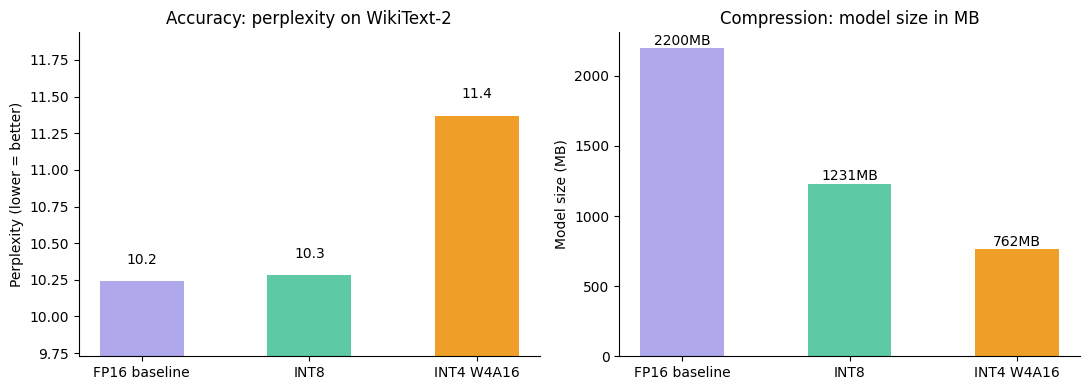

In [ ]:
import matplotlib.pyplot as plt

methods = [r['method'].split("(")[0].strip() for r in all_results]
ppl     = [r['perplexity'] for r in all_results]
sizes   = [r['model_size_mb'] for r in all_results]
colors  = ["#AFA9EC", "#5DCAA5", "#EF9F27"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.patch.set_facecolor("white")

# Perplexity
bars1 = ax1.bar(methods, ppl, color=colors, width=0.5, edgecolor="none")
ax1.set_ylabel("Perplexity (lower = better)")
ax1.set_title("Accuracy: perplexity on WikiText-2", fontweight="normal")
ax1.set_ylim(min(ppl) * 0.95, max(ppl) * 1.05)
for bar, val in zip(bars1, ppl):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val:.1f}", ha="center", va="bottom", fontsize=10)
ax1.spines[["top","right"]].set_visible(False)

# Size
bars2 = ax2.bar(methods, sizes, color=colors, width=0.5, edgecolor="none")
ax2.set_ylabel("Model size (MB)")
ax2.set_title("Compression: model size in MB", fontweight="normal")
for bar, val in zip(bars2, sizes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.0f}MB", ha="center", va="bottom", fontsize=10)
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/llm-quantization-benchmark/results/benchmark_chart.png",
            dpi=150, bbox_inches="tight")
plt.show()